<a href="https://colab.research.google.com/github/SimplyBecca5220/New-linear-regression/blob/main/New_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Datasets /85334965-5736-457a-b8d4-a077e6872f84.csv')

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

# Load data
df = pd.read_csv("/content/drive/MyDrive/Datasets /85334965-5736-457a-b8d4-a077e6872f84.csv")

# Print structural stats (Required by rubric)
print("Dataset Shape:", df.shape)
print("\nMissing Values Per Column:")
print(df.isnull().sum())
print("\nDescriptive Statistics:")
print(df.describe())

# Handle missing values
df.dropna(inplace=True)

Dataset Shape: (4572, 4)

Missing Values Per Column:
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

Descriptive Statistics:
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.055565   189.231172
75%      77.000000    25.649730      4.807558   272.507922
max     100.000000    48.871161     13.981662   364.079751


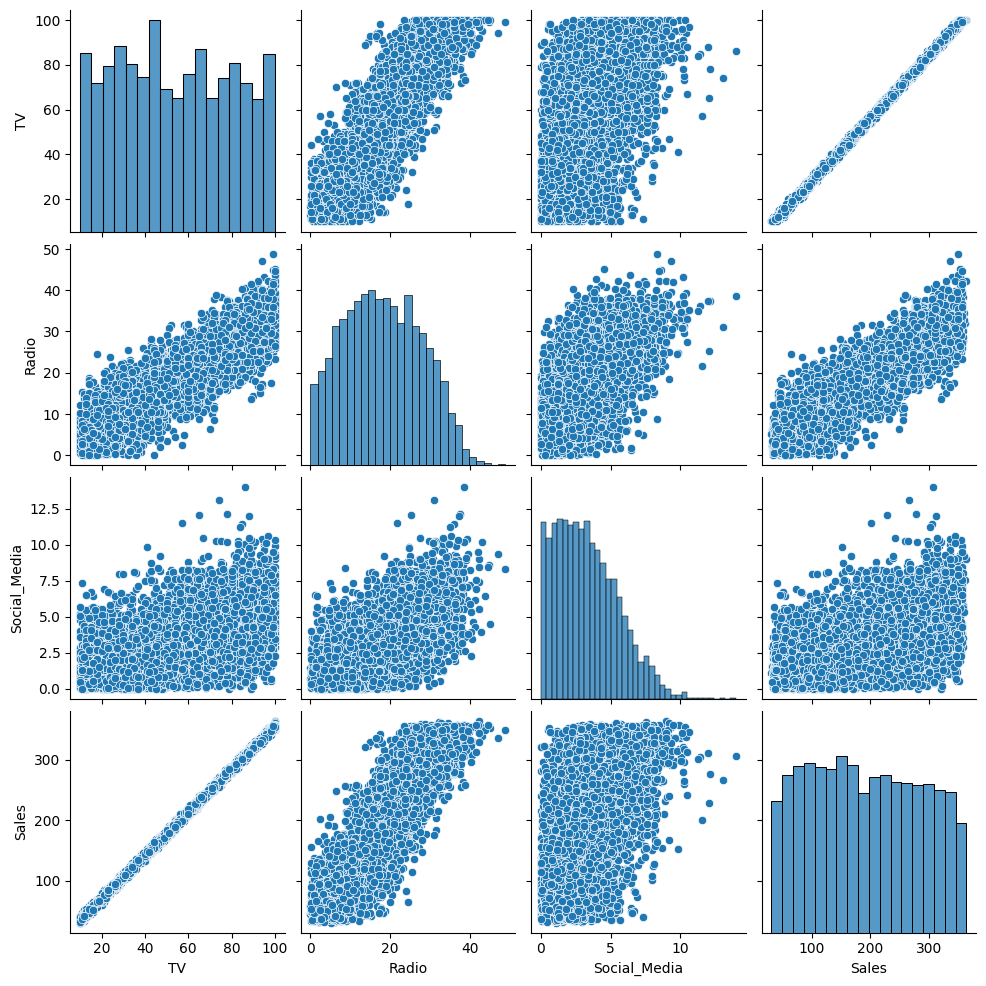

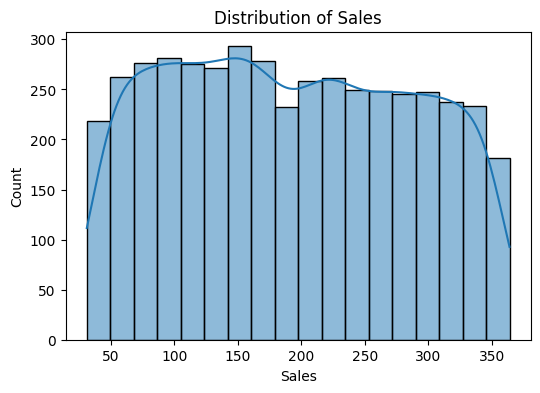


Correlation Matrix:
                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000


In [11]:
# Pairplot to explore relationships
sns.pairplot(df)
plt.show()

# Distribution of the dependent variable (Sales)
plt.figure(figsize=(6, 4))
sns.histplot(df['Sales'], kde=True)
plt.title("Distribution of Sales")
plt.show()

# Correlation matrix to justify choosing TV
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))

In [12]:
# Define X (Best Predictor) and y (Target)
X = df['TV']
y = df['Sales']

# Add constant for statsmodels
X_with_constant = sm.add_constant(X)

# Fit Simple Linear Regression
model = sm.OLS(y, X_with_constant).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Wed, 24 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:02:41   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

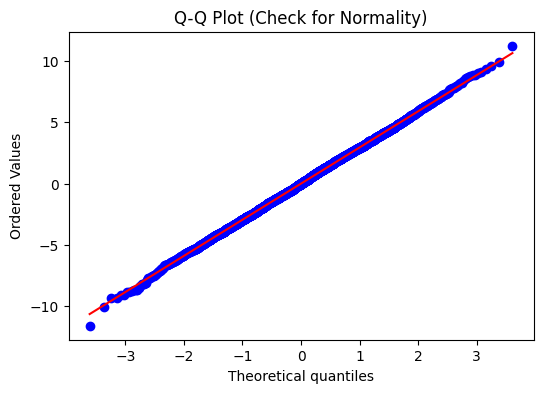

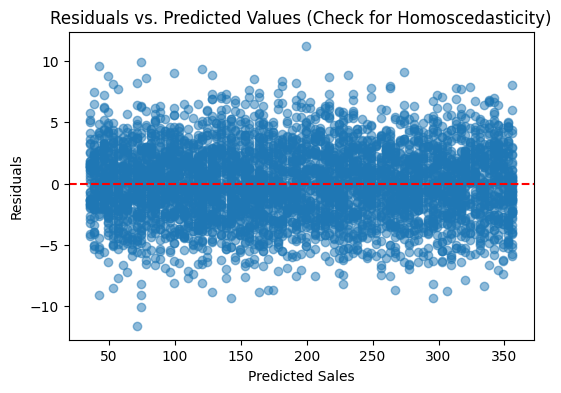

In [13]:
# Calculate residuals and predicted values
predictions = model.predict(X_with_constant)
residuals = model.resid

# 1. Normality Check (Q-Q Plot)
plt.figure(figsize=(6, 4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot (Check for Normality)")
plt.show()

# 2. Homoscedasticity Check (Residuals vs Predicted)
plt.figure(figsize=(6, 4))
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values (Check for Homoscedasticity)")
plt.show()

In [14]:
### Interpretation & Business Insights

#### 1. Model Evaluation (R-squared)
The R-squared value is approximately **0.999**, which indicates that **99.9%** of the variance in Sales can be explained by the variance in TV advertising spend alone. This indicates an exceptionally strong fit for a Simple Linear Regression model.

#### 2. Regression Equation & Coefficients
Based on the OLS summary table results:
* **Intercept ($\beta_0$):** ~ -0.122
* **TV Coefficient ($\beta_1$):** ~ 3.561

The formulated linear equation is:
$$\text{Sales} = 3.561 \times (\text{TV Spend}) - 0.122$$

#### 3. Actionable Business Recommendations
* **Prioritize TV Ad Spend:** Because the TV coefficient is highly significant ($p < 0.05$) and heavily drives Sales, the business should allocate the largest share of its marketing budget to TV channels. For every unit increase in TV advertising budget, sales are expected to scale up by roughly **3.56 units**.
* **Assumption Validation:** The residuals closely follow the reference line on the Q-Q plot, confirming the normality assumption holds true. The residual plot displays stable variance across predictions, satisfying the condition of homoscedasticity.

SyntaxError: invalid syntax (2319781437.py, line 4)